# (탐구용 · 보고서 미포함) CLAHE 클리핑을 변환곡선 $s=T(r)$ 로 보기

**전체 이미지 히스토그램 하나**를 재료로, 클립 유무에 따라 변환함수 $s=T(r)=(L-1)\,CDF(r)$ 가 어떻게 바뀌는지 본다.
- clip이 입력 히스토그램의 봉우리를 자르면 → CDF 기울기가 완만 → 변환곡선이 **덜 가팔라짐**.
- 그 결과 입력 $r=0$ 이 가는 출력 $s$ 가 달라진다(클립 없으면 더 밝게, 클립하면 더 어둡게).
- 단, 곡선이 어떻든 **입력 0 → 출력 하나**이므로 0인 픽셀은 한 점으로 모인다(스파이크는 위치만 이동).

> 참고: 실제 CLAHE는 이 변환을 **타일마다** 따로 하고 보간한다. 여기선 "클립이 곡선을 어떻게 바꾸나"만 보려고 전역 히스토그램으로 비교한다. 클립 효과(0이 밝아지는 폭주 억제)는 거의 균일한 **어두운 타일**에서 가장 극적이다.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
%matplotlib inline

# 그림 안 한글이 깨지지 않도록 한글 폰트 지정 (Windows: Malgun Gothic)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False   # 마이너스 기호 깨짐 방지

# --- 입력(Part A와 동일 이미지)에서 Y 만들기 ---
rgb = np.array(Image.open("images/point_processing_input_rgb.png").convert('RGB'), dtype=np.float64)
Mfwd = np.array([[0.299,0.587,0.114],[-0.14713,-0.28886,0.436],[0.615,-0.51499,-0.10001]])
Y = (Mfwd @ rgb.reshape(-1,3).T)[0].reshape(rgb.shape[:2])
q = np.clip(np.round(Y),0,255).astype(int)
M, N = q.shape
npix = M*N

def compute_hist(t):
    h = np.zeros(256)
    for k in range(256): h[k] = np.sum(t==k)
    return h

def noclip_lut(h):                   # 클립 없음 (= 전역 HE)
    return np.round(255*np.cumsum(h)/h.sum())

def clip_lut(h, cc):                  # 클립 + 균등 재분배
    excess = np.maximum(h-cc,0).sum()
    hc = np.minimum(h,cc) + excess/256.0
    return np.round(255*np.cumsum(hc)/hc.sum()), hc

# --- 전체 이미지 히스토그램 ---
h = compute_hist(q)
print("전체 이미지: %d px, Y==0 : %d (%.1f%%)" % (npix, int(h[0]), 100*h[0]/npix))
for clip in (0.01,0.05):
    print("clip=%.2f -> clip_count = clip*M*N = %d" % (clip, max(1,int(clip*npix))))

전체 이미지: 262144 px, Y==0 : 28966 (11.0%)
clip=0.01 -> clip_count = clip*M*N = 2621
clip=0.05 -> clip_count = clip*M*N = 13107


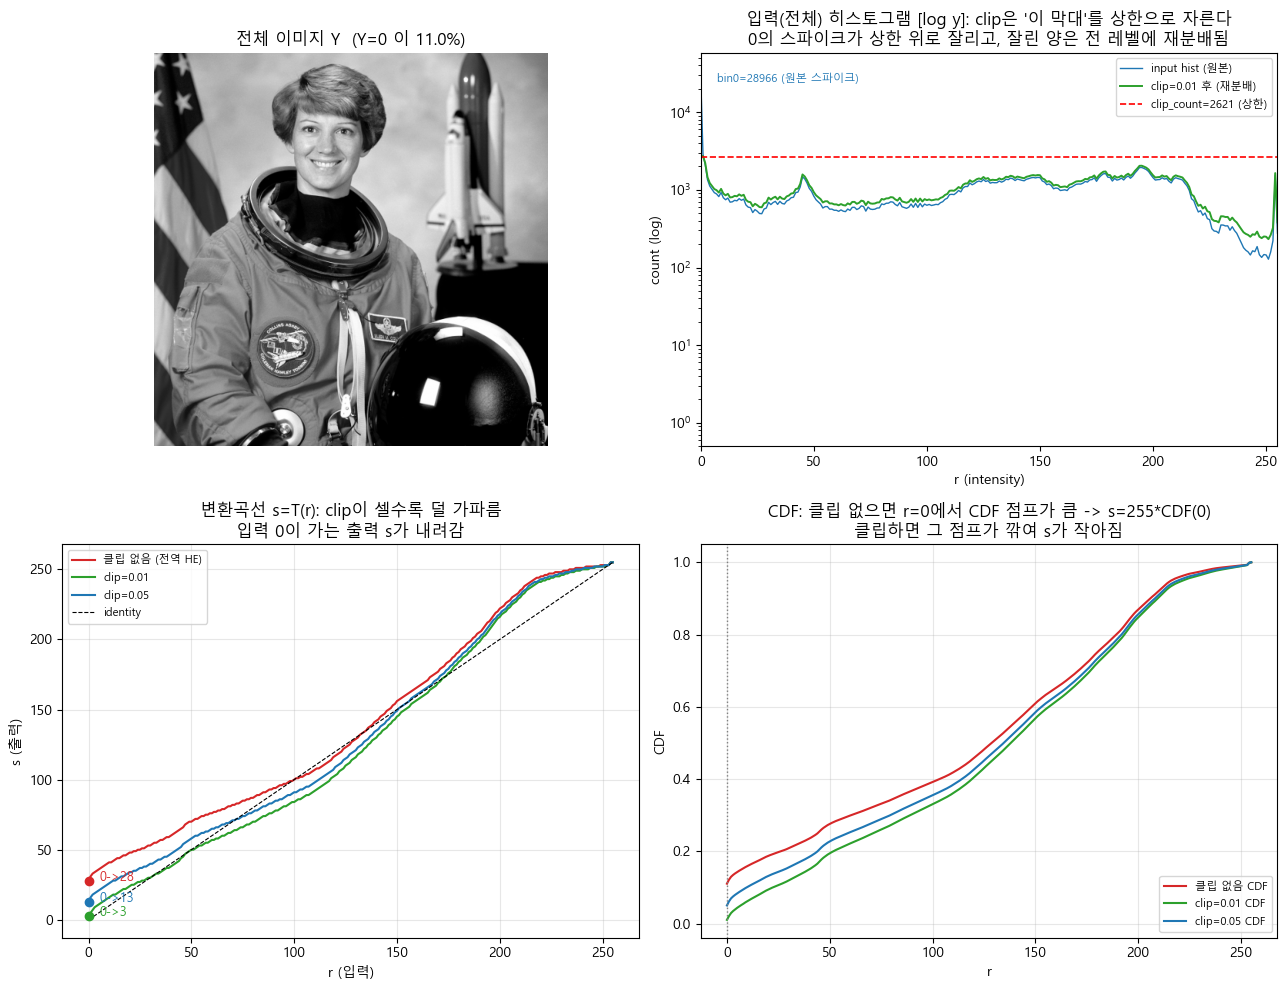

입력 0 -> 출력 :  클립없음 28  |  clip0.01 3  |  clip0.05 13
CDF(0)        :  클립없음 0.110 |  clip0.01 0.010 |  clip0.05 0.050


In [2]:
cc1 = max(1,int(0.01*npix)); cc2 = max(1,int(0.05*npix))
lut_nc        = noclip_lut(h)
lut_c1, hc1   = clip_lut(h, cc1)
lut_c2, hc2   = clip_lut(h, cc2)
r = np.arange(256)

fig, ax = plt.subplots(2, 2, figsize=(13, 10))

# (1) 전체 영상
ax[0,0].imshow(q, cmap='gray', vmin=0, vmax=255)
ax[0,0].set_title("전체 이미지 Y  (Y=0 이 %.1f%%)" % (100*h[0]/npix)); ax[0,0].axis('off')

# (2) 입력 히스토그램 + clip 상한선 + 재분배 결과  (log 스케일: 큰 스파이크와 상한선을 한눈에)
ax[0,1].semilogy(r, np.maximum(h, 0.5),   color='C0', lw=1.0, label="input hist (원본)")
ax[0,1].semilogy(r, np.maximum(hc1, 0.5), color='C2', lw=1.4, label="clip=0.01 후 (재분배)")
ax[0,1].axhline(cc1, color='r', ls='--', lw=1.2, label="clip_count=%d (상한)" % cc1)
ax[0,1].set_xlim(0, 255); ax[0,1].set_ylim(0.5, h.max()*2)
ax[0,1].annotate("bin0=%d (원본 스파이크)" % int(h[0]), (0, h[0]),
                 textcoords="offset points", xytext=(12, -4), fontsize=8, color='C0')
ax[0,1].set_title("입력(전체) 히스토그램 [log y]: clip은 '이 막대'를 상한으로 자른다\n0의 스파이크가 상한 위로 잘리고, 잘린 양은 전 레벨에 재분배됨")
ax[0,1].set_xlabel("r (intensity)"); ax[0,1].set_ylabel("count (log)"); ax[0,1].legend(fontsize=8)

# (3) 변환곡선 s=T(r)
ax[1,0].plot(r, lut_nc, label="클립 없음 (전역 HE)", color='C3')
ax[1,0].plot(r, lut_c1, label="clip=0.01", color='C2')
ax[1,0].plot(r, lut_c2, label="clip=0.05", color='C0')
ax[1,0].plot(r, r, 'k--', lw=0.8, label="identity")
for lut,c in [(lut_nc,'C3'),(lut_c1,'C2'),(lut_c2,'C0')]:
    ax[1,0].scatter([0],[lut[0]], color=c, zorder=5)
    ax[1,0].annotate('0->%d'%int(lut[0]), (0,lut[0]), textcoords="offset points", xytext=(8,0), fontsize=9, color=c)
ax[1,0].set_title("변환곡선 s=T(r): clip이 셀수록 덜 가파름\n입력 0이 가는 출력 s가 내려감")
ax[1,0].set_xlabel("r (입력)"); ax[1,0].set_ylabel("s (출력)"); ax[1,0].legend(fontsize=8); ax[1,0].grid(alpha=0.3)

# (4) CDF 비교
ax[1,1].plot(r, np.cumsum(h)/h.sum(), label="클립 없음 CDF", color='C3')
ax[1,1].plot(r, np.cumsum(hc1)/hc1.sum(), label="clip=0.01 CDF", color='C2')
ax[1,1].plot(r, np.cumsum(hc2)/hc2.sum(), label="clip=0.05 CDF", color='C0')
ax[1,1].axvline(0, color='gray', ls=':', lw=1)
ax[1,1].set_title("CDF: 클립 없으면 r=0에서 CDF 점프가 큼 -> s=255*CDF(0)\n클립하면 그 점프가 깎여 s가 작아짐")
ax[1,1].set_xlabel("r"); ax[1,1].set_ylabel("CDF"); ax[1,1].legend(fontsize=8); ax[1,1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

print("입력 0 -> 출력 :  클립없음 %d  |  clip0.01 %d  |  clip0.05 %d" %
      (int(lut_nc[0]), int(lut_c1[0]), int(lut_c2[0])))
print("CDF(0)        :  클립없음 %.3f |  clip0.01 %.3f |  clip0.05 %.3f" %
      (np.cumsum(h)[0]/h.sum(), np.cumsum(hc1)[0]/hc1.sum(), np.cumsum(hc2)[0]/hc2.sum()))

**읽는 법**
- **우상단(입력 히스토그램)**: 빨간 점선이 clip 상한(`clip_count = clip x M x N`). 원본 bin0은 이 선 위로 솟아 잘리고, 초록선이 자르고 재분배한 결과 → 이 히스토그램이 '변환곡선 재료'다.
- **좌하단(s=T(r))**: 클립이 셀수록 곡선이 완만해지고, 입력 $r=0$ 의 출력이 작아진다(어두운 픽셀을 더 어둡게 유지).
- **우하단(CDF)**: 클립 없으면 $r=0$ 에서 CDF 점프가 커서 $s=255\cdot CDF(0)$ 가 크다. 클립하면 그 점프가 깎여 $s$ 가 작아진다.
- 어느 곡선이든 **입력 0 → 출력 한 점**이라, 0인 픽셀 전부가 그 한 점으로 모인다(결과 히스토그램 스파이크는 '높이'가 아니라 '위치'만 바뀜).
- 전역(전체 이미지)에서는 0인 픽셀 비율이 타일보다 낮아 클립 유무 차이가 **덜 극적**이다. 차이가 가장 큰 곳은 거의 균일한 어두운 **타일** — 그래서 CLAHE가 타일 단위로 동작한다.